# SOFTMAX logistic regression from scratch - Pseudocode
Goal: learn a linear classifier which maps an input ofpixels (image) to prgbabilities belonging to class outcomes from 0 - 9 on the mnist dtaset using softmax and cross-entropy loss


SOFTMAX LOGISTIC REGRESSION (FROM SCRATCH) — PSEUDOCODE

Goal:
Learn a linear classifier that maps an input image to probabilities
over 10 digit classes using softmax and cross-entropy loss.

------------------------------------------------------------
1) Initialize
------------------------------------------------------------
- Load and normalize the dataset
- Flatten each image into a vector
- Initialize weight matrix W with small random values
- Initialize bias vector b with zeros

------------------------------------------------------------
2) Training loop (repeat for several epochs)
------------------------------------------------------------

For each epoch:

        Shuffle the training data

        For each mini-batch:
            a. Forward pass
                - Compute raw class scores (logits):
                    scores = X_batch * W + b
                - Convert scores into probabilities using softmax

            b. Compute loss
                - Use cross-entropy loss:
                    loss = average negative log probability of the true class

            c. Backward pass
                - Compute gradient of loss w.r.t. scores:
                    grad_scores = (probabilities - true_labels)
                - Compute gradients for weights and biases:
                    grad_W = X_batch^T * grad_scores
                    grad_b = sum of grad_scores

            d. Update parameters
                - Subtract learning_rate * gradient from W and b


------------------------------------------------------------
3) Evaluation
------------------------------------------------------------
- Compute scores on test data
- Apply softmax
- Predict the class with highest probability
- Measure accuracy

------------------------------------------------------------
Key ideas:
------------------------------------------------------------
- Each class has a linear template (weights)
- Softmax converts scores into probabilities
- Cross-entropy penalizes confident wrong predictions
- Gradient descent adjusts weights to improve accuracy
- The model learns linear decision boundaries in pixel space


Epoch 1/80 — Test Accuracy: 0.8887
Epoch 2/80 — Test Accuracy: 0.9004
Epoch 3/80 — Test Accuracy: 0.9059
Epoch 4/80 — Test Accuracy: 0.9091
Epoch 5/80 — Test Accuracy: 0.9119
Epoch 6/80 — Test Accuracy: 0.9135
Epoch 7/80 — Test Accuracy: 0.9137
Epoch 8/80 — Test Accuracy: 0.9176
Epoch 9/80 — Test Accuracy: 0.9173
Epoch 10/80 — Test Accuracy: 0.9164
Epoch 11/80 — Test Accuracy: 0.9174
Epoch 12/80 — Test Accuracy: 0.9189
Epoch 13/80 — Test Accuracy: 0.9188
Epoch 14/80 — Test Accuracy: 0.9183
Epoch 15/80 — Test Accuracy: 0.9201
Epoch 16/80 — Test Accuracy: 0.9192
Epoch 17/80 — Test Accuracy: 0.9197
Epoch 18/80 — Test Accuracy: 0.9199
Epoch 19/80 — Test Accuracy: 0.9195
Epoch 20/80 — Test Accuracy: 0.9217
Epoch 21/80 — Test Accuracy: 0.9213
Epoch 22/80 — Test Accuracy: 0.9217
Epoch 23/80 — Test Accuracy: 0.9218
Epoch 24/80 — Test Accuracy: 0.9217
Epoch 25/80 — Test Accuracy: 0.9222
Epoch 26/80 — Test Accuracy: 0.9219
Epoch 27/80 — Test Accuracy: 0.9221
Epoch 28/80 — Test Accuracy: 0.9229
E

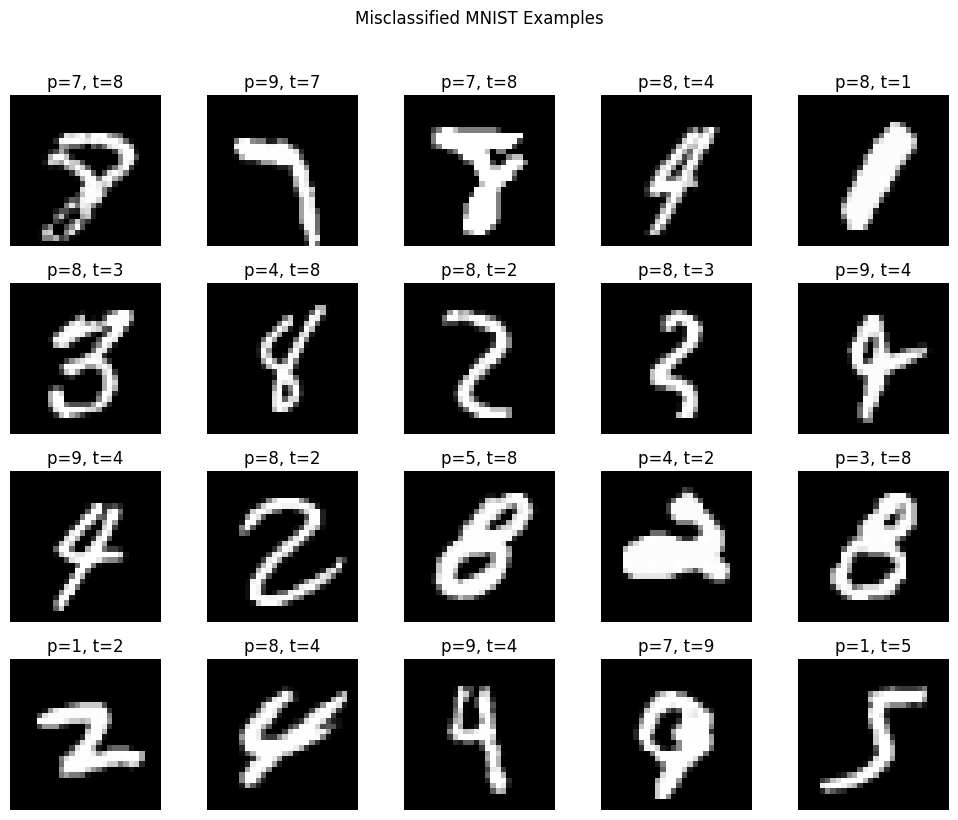

In [4]:
# ==============================================================================
# IMPORTS AND DATA LOADING
# ==============================================================================
import numpy as np
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ==============================================================================
# PREPROCESSING: Getting the data ready for our model
# ==============================================================================

# Normalize pixel values to be between 0 and 1
# (they start out as integers 0-255, which is weird for math)
# Also flatten each image from a 2D grid (28x28) into a 1D vector (784 values)
# basically unrolling the image into a single row
X_train = (x_train.astype(np.float32) / 255.0).reshape(-1, 784)
X_test  = (x_test.astype(np.float32) / 255.0).reshape(-1, 784)

# N = number of training samples (60,000)
# D = number of features per image (784 pixels)
# C = number of classes (10 digits: 0 through 9)
N, D = X_train.shape
C = 10

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def one_hot(y, num_classes=10):
    # Convert class labels into one-hot encoded vectors
    # Our loss function needs this format to compare predicted probabilities
    # against true labels mathematically.
    # Parameters: y = array of class labels (0-9)
    #             num_classes = number of different classes (10 for MNIST)
    # Returns: 2D array where each row is a one-hot vector
    Y = np.zeros((y.size, num_classes))
    Y[np.arange(y.size), y] = 1
    return Y


def softmax(Z):
    # Convert raw scores (logits) into probabilities that sum to 1
    # We computed some score for each digit class, and softmax squashes them
    # into a probability distribution. High scores → high probs, low → low.
    # Example: [1.0, 2.0, 0.5] becomes [0.21, 0.58, 0.21] (sums to 1)
    # Parameters: Z = raw scores/logits from our model (N x C where N=samples, C=classes)
    # Returns: same shape as Z, but each row sums to 1 (probabilities)
    
    # Subtract the max value in each row to avoid numerical explosion
    # this is important for numerical stability (prevents numbers expanding too much)
    # when we exponentiate them
    # (doesn't change the result, just keeps numbers safe)
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    
    # Exponentiate each value (this is what softmax does)
    exp_Z = np.exp(Z_shifted)
    
    # Divide by the sum to normalize into probabilities
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


def accuracy(y_true, y_pred):
    # Simple metric: what fraction of our predictions were correct?
    return np.mean(y_true == y_pred)


# ==============================================================================
# PREPARE DATA FOR TRAINING
# ==============================================================================

# Convert label arrays into one-hot format
# (required by  loss function and training algorithm)
Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)

# ==============================================================================
# INITIALIZE THE MODEL PARAMETERS
# ==============================================================================

# Set random seed for reproducibility
np.random.seed(42)

# Weight matrix W: shape is (784, 10)
# basically: 10 "templates" - one for each digit
# Each template has 784 values (one per pixel)
# The model learns these weights to recognize digits
# initialize with small random values cuz lazy and it works
W = 0.01 * np.random.randn(D, C)

# Bias vector b: shape is (10,)
# This is just an offset for each class
# It's like saying "add this amount to the score for digit 0,
# add this amount for digit 1", etc.
# basically "prior" or baseline for each class
b = np.zeros(C)

# ==============================================================================
# TRAINING HYPERPARAMETERS
# ==============================================================================

# Learning rate: controls how big the weight updates are
# Too high → model overshoot and the loss bounces around wildly
# Too low → training is super slow
# 0.1 is a decent middle ground for this problem
learning_rate = 0.1

# More epochs = more training, but diminishing returns and risk of overfitting
epochs = 80

# Batch size: how many images we process before updating weights
# Smaller batches = noisier gradients but faster training
# Larger batches = cleaner gradients but slower per-update
batch_size = 256

# ==============================================================================
# TRAINING LOOP
# ==============================================================================

for epoch in range(epochs):
    # Each epoch, we go through all the training data and update our weights
    
    # Shuffle the training data so we don't process it in the same order
    # each epoch (helps the model generalize better)
    perm = np.random.permutation(N)
    X_train_shuffled = X_train[perm]
    Y_train_shuffled = Y_train[perm]
    
    # Process the training data in mini-batches
    # (instead of all 60k images at once, we do 256 at a time)
    # This is more efficient and helps with gradient estimation
    for i in range(0, N, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]  # Get a chunk of images
        Y_batch = Y_train_shuffled[i:i+batch_size]  # Get their labels
        
        # ====================================================================
        # FORWARD PASS: Compute predictions
        # ====================================================================
        
        # Compute raw scores (logits) for each image
        # This is the linear part: score = image_pixels @ weights + bias
        # Shape: (batch_size, 10) - we get 10 scores per image
        Z = X_batch @ W + b
        
        # Convert scores into probabilities using softmax
        # Now Z[i, j] tells us "how confident we are that image i is digit j"
        # All probabilities for one image sum to 1
        P = softmax(Z)
        
        # ====================================================================
        # BACKWARD PASS: Compute gradients (how to improve our weights)
        # ====================================================================
        
        # The KEY insight of softmax + cross-entropy loss:
        # The gradient w.r.t. logits is just (P - Y_batch) / batch_size
        # 
        # Why? Because cross-entropy loss is specifically designed so that
        # when you combine it with softmax, the gradient has this nice form.
        # It's the difference between what we predicted (P) and what's true (Y_batch)
        # softmax + cross-entropy is a common combo in classification tasks since the gradient
        # is literally subtracting the true labels from the predicted probabilities.
        # 
        # Example: if true label is [1,0,0] and we predicted [0.7, 0.2, 0.1],
        # then dZ = ([0.7, 0.2, 0.1] - [1, 0, 0]) / batch_size
        #        = ([-0.3, 0.2, 0.1]) / batch_size
        # This tells us: "reduce score for class 0, increase for class 1 and 2"
        dZ = (P - Y_batch) / X_batch.shape[0]
        
        # Gradient for weights: how much we should change each weight
        # This is computed by multiplying the input images (transposed)
        # with the gradient  computed above
        # Shape: (784, 10) - same as W
        dW = X_batch.T @ dZ
        
        # Gradient for biases: sum up all the gradients for each class
        # Shape: (10,) - same as b
        db = np.sum(dZ, axis=0)
        
        # ====================================================================
        # PARAMETER UPDATE: Apply gradients to improve our model
        # ====================================================================
        
        # Standard gradient descent: move in the opposite direction of the gradient
        # We subtract because we want to minimize loss, so we move downhill
        W -= learning_rate * dW
        b -= learning_rate * db
    
    # ========================================================================
    # EVALUATION: 
    # ========================================================================
    
    # After going through all training data, check our accuracy on test set
    # (data the model has never seen)
    
    # Forward pass on test data (no mini-batches, just all at once)
    Z_test = X_test @ W + b
    P_test = softmax(Z_test)
    
    # Get the predicted class for each test image
    # argmax = "which class has the highest probability?"
    y_pred = np.argmax(P_test, axis=1)
    
    # Compute accuracy
    acc = accuracy(y_test, y_pred)
    print(f"Epoch {epoch + 1}/{epochs} — Test Accuracy: {acc:.4f}")
    
def show_misclassified_examples(images, y_true, y_pred, n=20, title=""):
    """Show a reproducible sample of misclassified images with predicted/true labels."""
    mis_idx = np.where(y_true != y_pred)[0]
    if len(mis_idx) == 0:
        print("No misclassified examples to show.")
        return

    n = min(n, len(mis_idx))
    # Sample using the seeded RNG so results are stable across runs
    chosen = RNG.choice(mis_idx, size=n, replace=False)

    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 2 * rows))
    for i, idx in enumerate(chosen, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(images[idx], cmap="gray")
        plt.title(f"p={y_pred[idx]}, t={y_true[idx]}")
        plt.axis("off")
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
import matplotlib.pyplot as plt
RNG = np.random.default_rng(42)  # For reproducible sampling
show_misclassified_examples(x_test, y_test, y_pred, n=20, title="Misclassified MNIST Examples")
